 # Experiment 3: Regression Analysis using Linear and Regularized Models
To implement linear and regularized regression models for predicting a continuous target variable,
evaluate their performance using multiple metrics, visualize model behavior, and analyze overfitting,
underfitting, and bias–variance characteristics.


## 1. Dataset Analysis and EDA

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler


def eda(df):
    print("-" * 60)
    print("DATASET OVERVIEW")

    print("Dimensions:", df.shape)
    print("\nFirst 5 rows:")
    print(df.head())

    print("\nColumns:")
    for col in df.columns:
        print(col)

    dup = df.duplicated().sum()

    print("\nDuplicate rows:", dup)

    if dup > 0:
        df = df.drop_duplicates()
        print("Duplicate rows removed.")

    print("-" * 60)
    print("MISSING VALUE ANALYSIS")

    missing = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    print("\n")
    print(f"Number of missing values: {missing}")

    # Plot missing values
    plt.figure(figsize=(10, 5))
    plt.bar(df.columns, df.isnull().sum())
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.title("Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    
    #Remove columns with > 50% missing values
    
    missing_threshold = 50

    columns_to_drop = missing_percentage[missing_percentage > missing_threshold].index.tolist()

    if columns_to_drop:
        print("\nColumns removed because of excessive missing values:")
        for col in columns_to_drop: 
            print("column: " + col + " missing percentage: " + missing_percentage[col])
        df = df.drop(columns=columns_to_drop)

    else:
        print("\nNo columns have more than 50% missing values.")

    #Remove constant columns

    constant_columns = []    

    for col in df.columns:
            if df[col].nunique(dropna=False) <= 1:
                constant_columns.append(col)

    if constant_columns:
        print("\nConstant columns removed:")
        for col in constant_columns:
            print(col)
        df = df.drop(columns=constant_columns)

 
    #Seperate numerical and categorical features

    num_cols = df.select_dtypes(include=np.number).columns.tolist()

    cat_cols = df.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    print("\nNumerical columns:")
    print(num_cols)

    print("\nCategorical columns:")
    print(cat_cols)

    
    #Missing value imputation
    
    print("-" * 60)
    print("MISSING VALUE IMPUTATION")

    for col in num_cols:
        if df[col].isnull().sum() > 0:
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)

    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            mode = df[col].mode()
            if not mode.empty:
                mode_value = mode[0]
                df[col] = df[col].fillna(mode_value)

    print("Missing values imputed!")

    
    # outlier handling
    

    print("-" * 60)
    print("OUTLIER DETECTION")

    
    outlier_percentage_threshold = 15

    for col in num_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_df = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        )
        out_cnt = outlier_df.sum()
        outlier_percentage = (out_cnt / len(df)) * 100
        print(f"{col}: {out_cnt} outliers, percentage: {outlier_percentage}")

        if outlier_percentage == 0:
            print("No outliers detected.")

        elif outlier_percentage <= outlier_percentage_threshold:
            median_value = df[col].median()
            df.loc[outlier_df, col] = median_value

            print("Few outliers detected.")
            print(f"Replaced with median ({median_value}).")

        elif outlier_percentage >= outlier_percentage_threshold:

            df.loc[df[col] < lower_bound, col] = lower_bound
            df.loc[df[col] > upper_bound, col] = upper_bound

            print("Moderate outliers detected.")
            print("Values changed to IQR boundaries")

    print("-" * 60)
    print("NUMERICAL FEATURES VISUALIZATION")
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"{col} - Distribution")
        axes[0].set_xlabel(col)

        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"{col} - Boxplot")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

    # Numerical feature analysis

    print("-" * 60)
    print("NUMERICAL FEATURE TRANSFORMATION")

    for col in num_cols:
        skewness = df[col].skew()
        print(f"{col}: skewness = {skewness}")
        if abs(skewness) > 1:
            if (df[col] >= 0).all():
                df[col] = np.log1p(df[col])
                print("Highly skewed and non-negative.")
                print("Applied log1p transformation.")
            else:
                scaler = StandardScaler()
                df[[col]] = scaler.fit_transform(df[[col]])

                print("Highly skewed but contains negative values. Applied StandardScaler.")
        else:
            scaler = StandardScaler()
            df[[col]] = scaler.fit_transform(df[[col]])
            print("Distribution is reasonably symmetric.")
            print("Applied StandardScaler.")

    #Categorical feature analysis

    print("-" * 60)
    print("CATEGORICAL FEATURE ANALYSIS")

    for col in cat_cols:
        counts = df[col].value_counts()
        if len(counts) > 30:
            print(f"Skipping {col} because it has too many categories.")
            continue
        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=df,
            x=col,
            order=counts.index
        )

        plt.title(f"Count Plot - {col}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    
    # Encode categorical values
    
    print("-" * 60)
    print("CATEGORICAL ENCODING")

    for col in cat_cols:
        unique_count = df[col].nunique()
        if unique_count > 30:
            print(f"Skipping {col} because it has too many categories.")
            continue
        if unique_count == 2:
            values = df[col].unique()
            mapping = {values[0]: 0, values[1]: 1}
            df[col] = df[col].map(mapping)
            print(f"{col}: Binary encoding -> {mapping}")

        else:

            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
            df = pd.concat([df.drop(columns=[col]), dummies],axis=1)
            print(f"{col}: One-hot encoded ")
            print(f"{unique_count} categories")


    # Final dataset

    print("-" * 60)
    print("FINAL DATASET")

    print("Final dimensions:", df.shape)

    print("Remaining columns:")
    print(df.columns.tolist())

    print("Remaining missing values:")
    print(df.isnull().sum())

    print("Final dataframe:")
    print(df.head())

    return df

------------------------------------------------------------
DATASET OVERVIEW
Dimensions: (30000, 24)

First 5 rows:
  Customer ID               Name Gender  Age  Income (USD) Income Stability  \
0     C-36995   Frederica Shealy      F   56       1933.05              Low   
1     C-33999  America Calderone      M   32       4952.91              Low   
2      C-3770      Rosetta Verne      F   65        988.19             High   
3     C-26480         Zoe Chitty      F   65           NaN             High   
4     C-23459       Afton Venema      F   31       2614.77              Low   

  Profession     Type of Employment    Location  Loan Amount Request (USD)  \
0    Working            Sales staff  Semi-Urban                   72809.58   
1    Working                    NaN  Semi-Urban                   46837.47   
2  Pensioner                    NaN  Semi-Urban                   45593.04   
3  Pensioner                    NaN       Rural                   80057.92   
4    Working  High

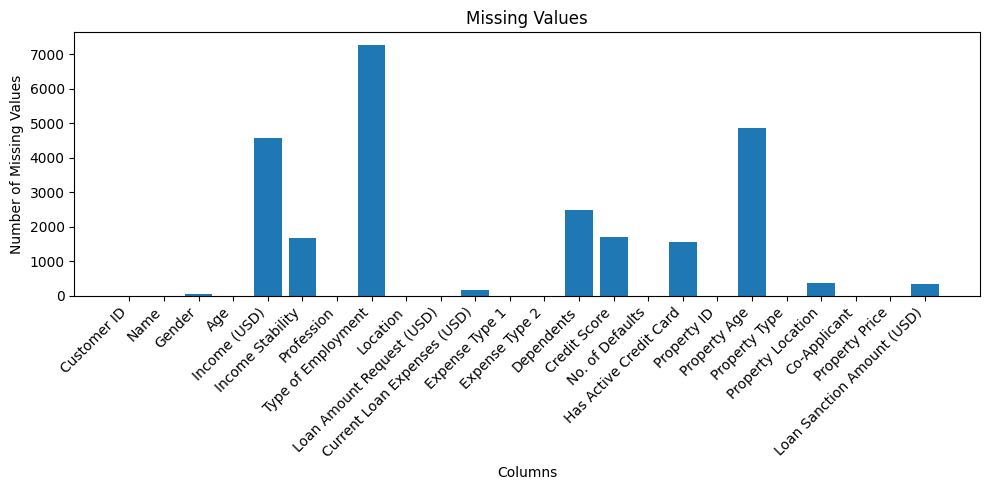


No columns have more than 50% missing values.

Numerical columns:
['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']

Categorical columns:
['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']
------------------------------------------------------------
MISSING VALUE IMPUTATION
Missing values imputed!
------------------------------------------------------------
OUTLIER DETECTION
Age: 0 outliers, percentage: 0.0
No outliers detected.
Income (USD): 1874 outliers, percentage: 6.246666666666666
Few outliers detected.
Replaced with median (2222.435).
Loan Amount Request (USD): 752 outliers, percentage: 2.506666666666667
Few outliers detected.
Replaced with median (75128.

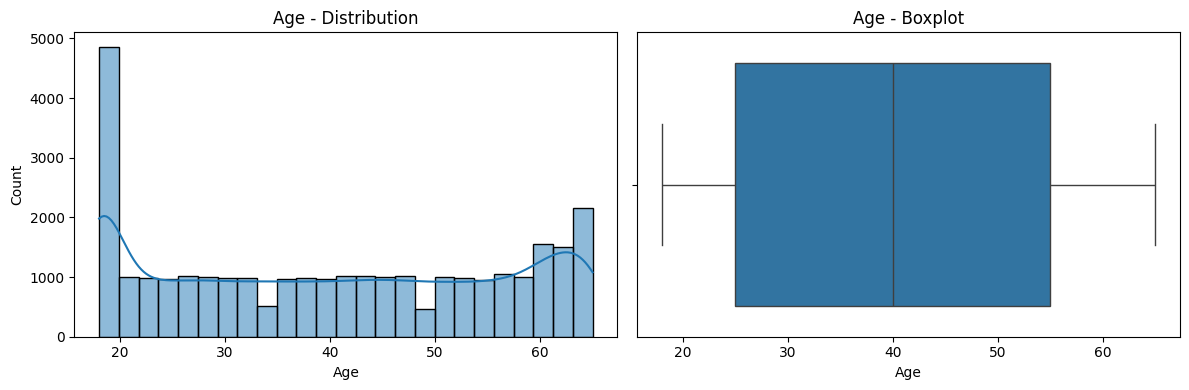

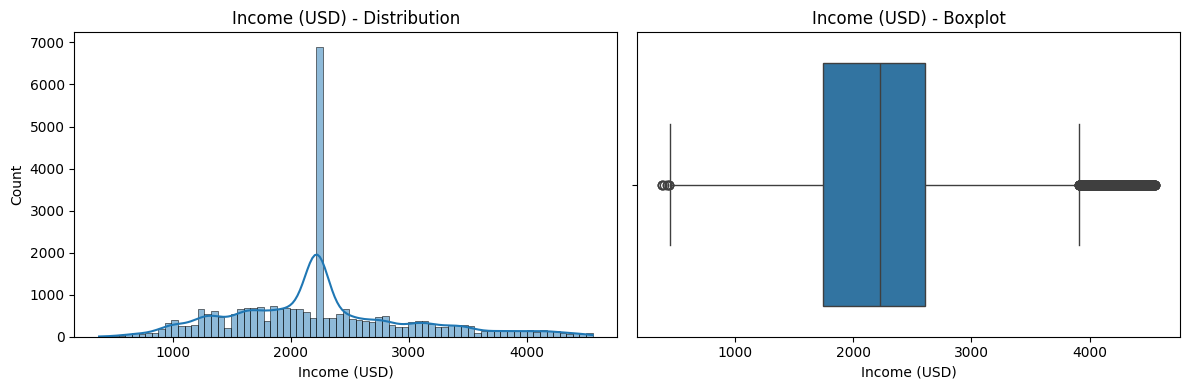

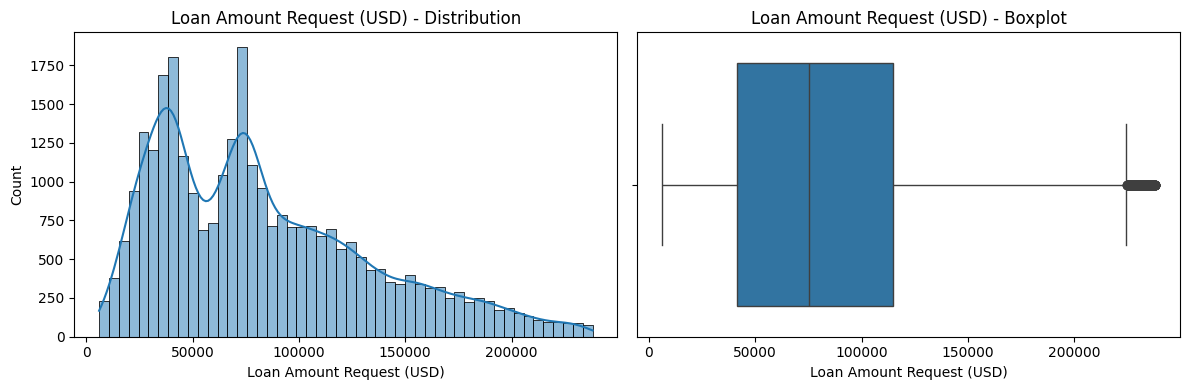

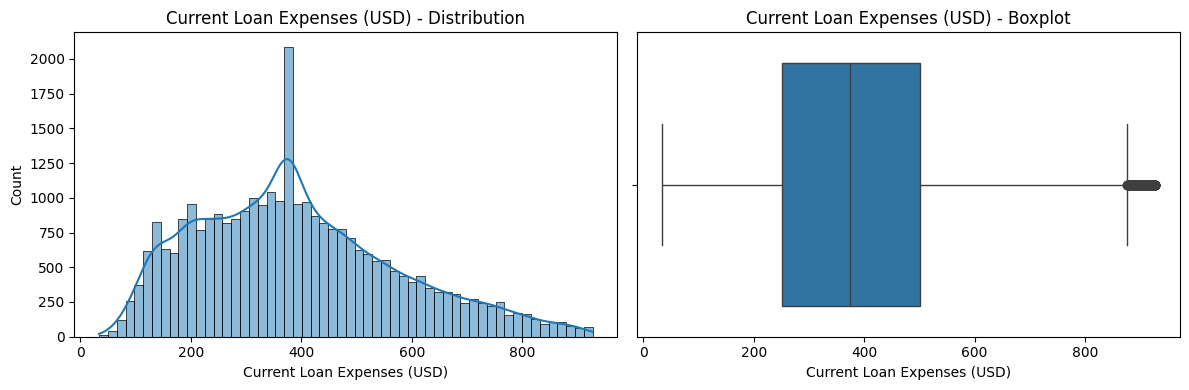

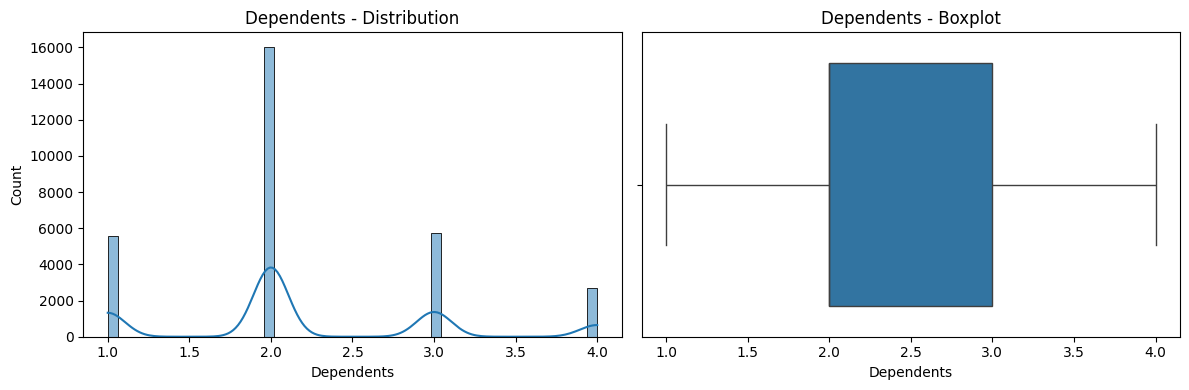

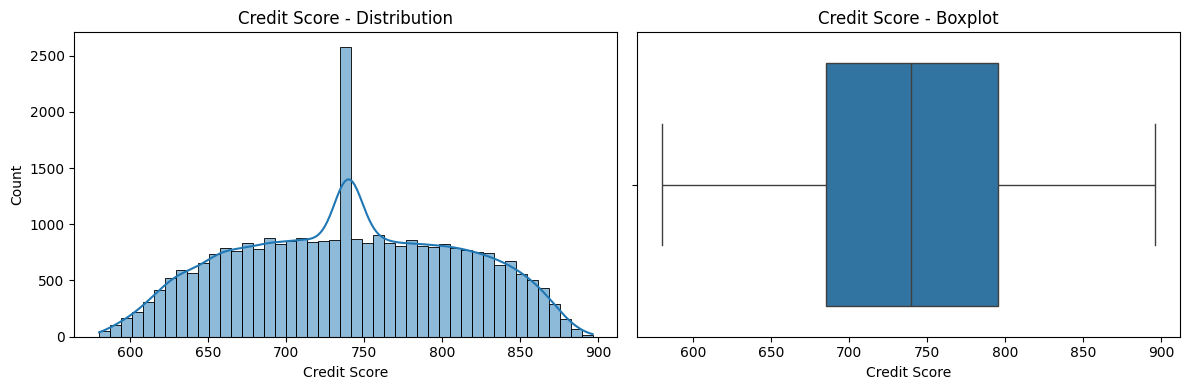

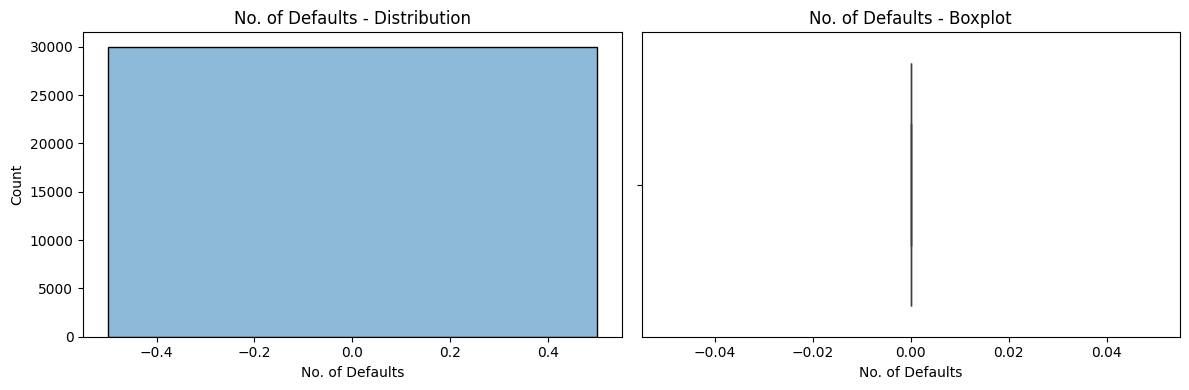

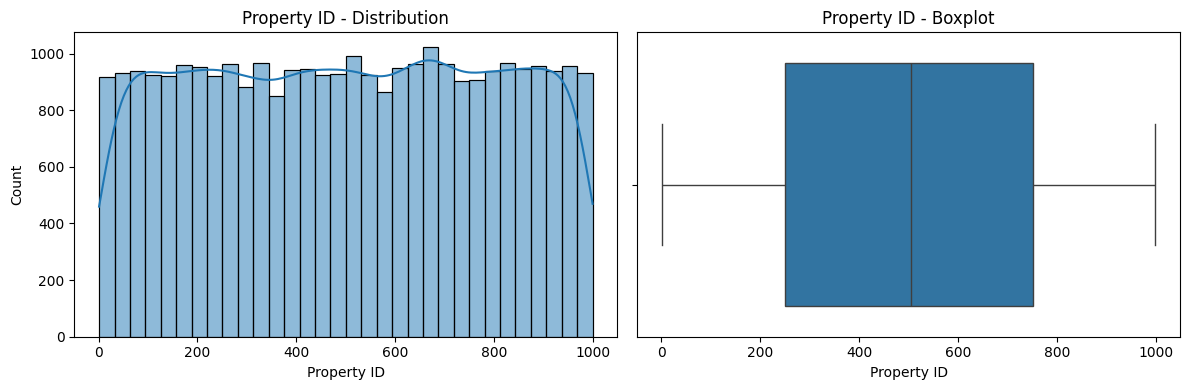

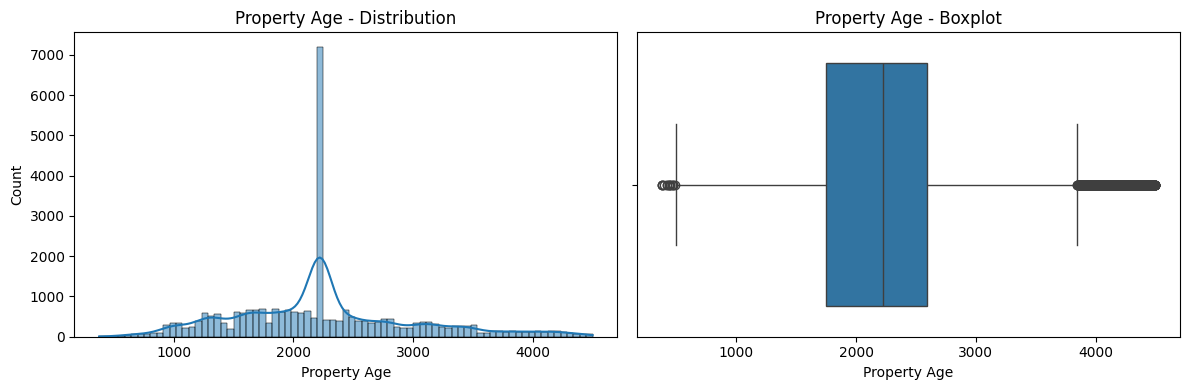

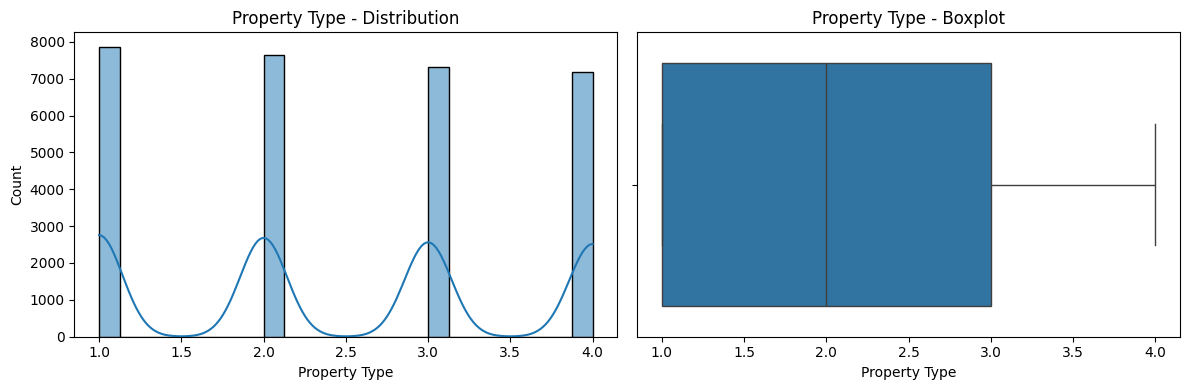

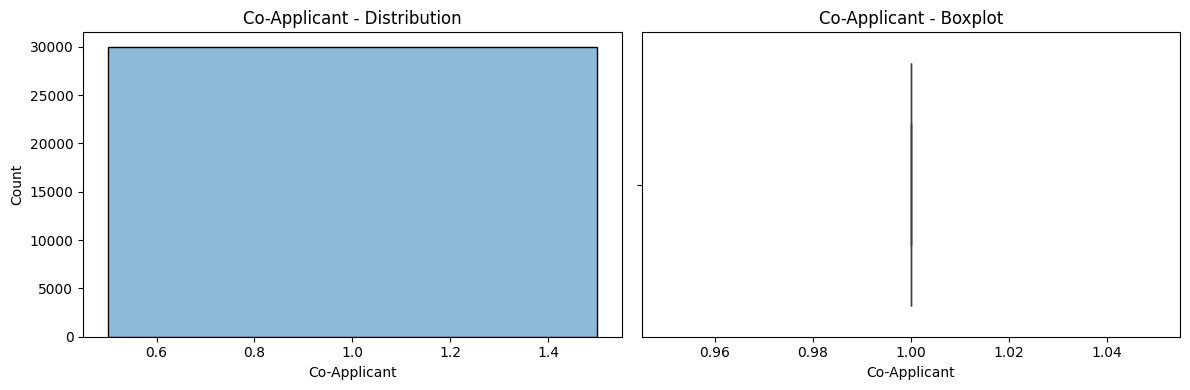

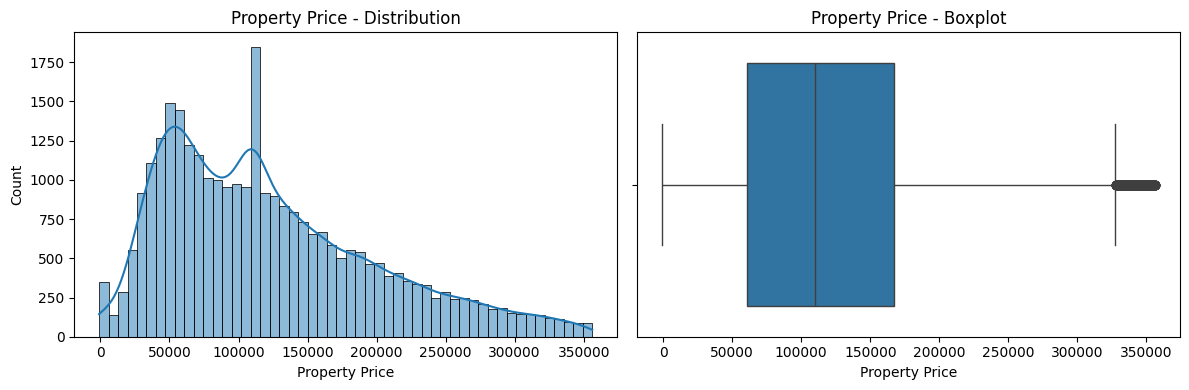

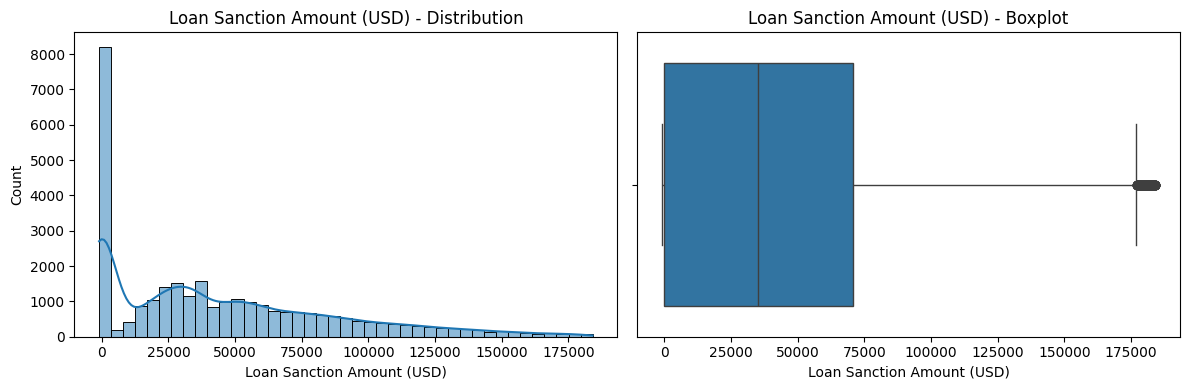

------------------------------------------------------------
NUMERICAL FEATURE TRANSFORMATION
Age: skewness = 0.046093801598670575
Distribution is reasonably symmetric.
Applied StandardScaler.
Income (USD): skewness = 0.6050985571994248
Distribution is reasonably symmetric.
Applied StandardScaler.
Loan Amount Request (USD): skewness = 0.8144025243752381
Distribution is reasonably symmetric.
Applied StandardScaler.
Current Loan Expenses (USD): skewness = 0.5616744332800275
Distribution is reasonably symmetric.
Applied StandardScaler.
Dependents: skewness = 0.560014326304551
Distribution is reasonably symmetric.
Applied StandardScaler.
Credit Score: skewness = -0.02069683024344066
Distribution is reasonably symmetric.
Applied StandardScaler.
No. of Defaults: skewness = 0.0
Distribution is reasonably symmetric.
Applied StandardScaler.
Property ID: skewness = -0.010519189724274057
Distribution is reasonably symmetric.
Applied StandardScaler.
Property Age: skewness = 0.5838257164690455
Dist

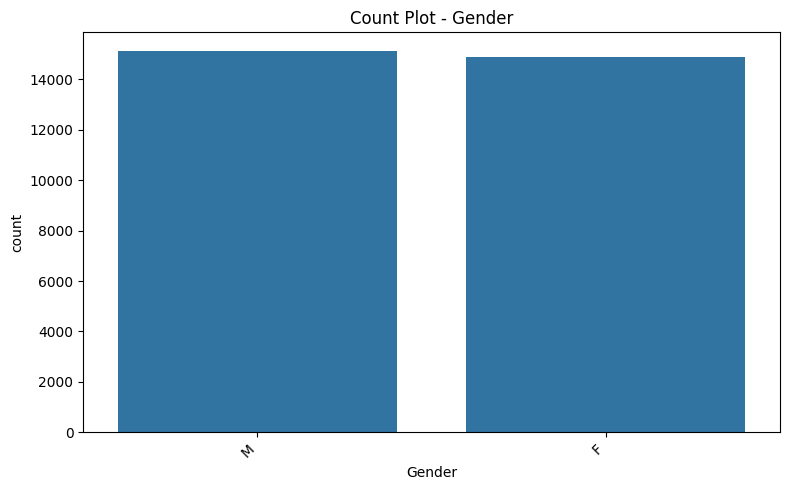

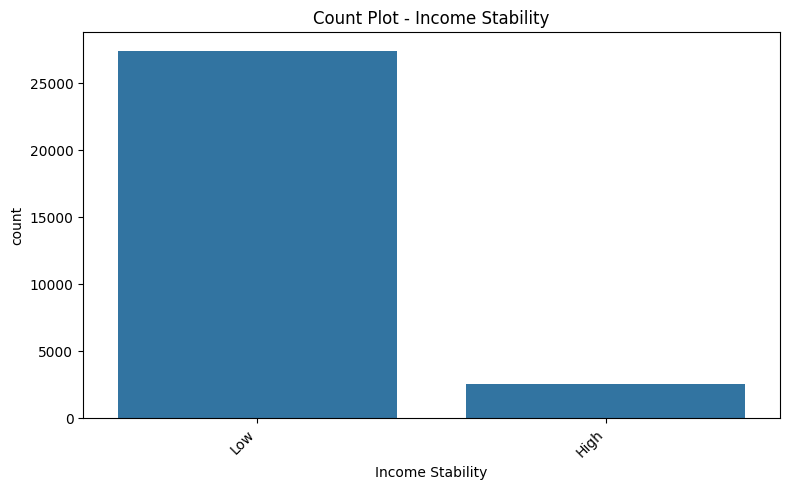

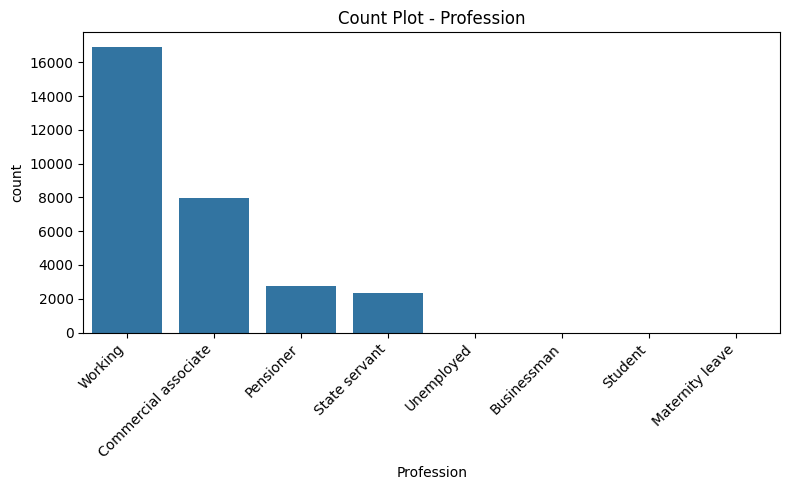

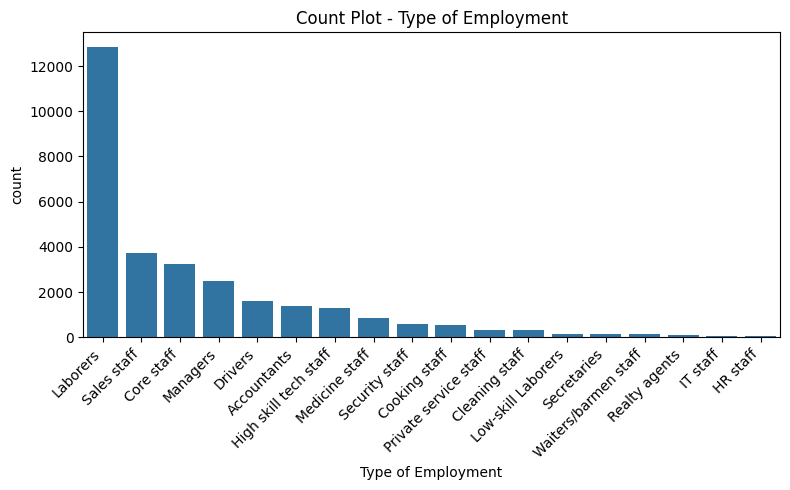

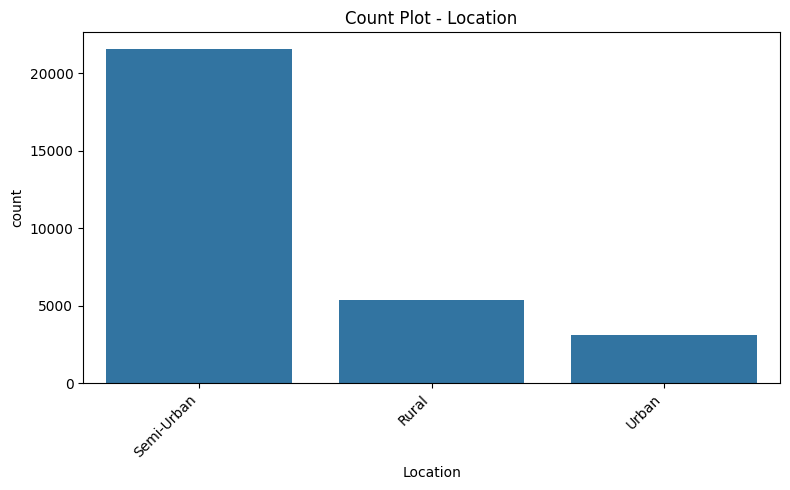

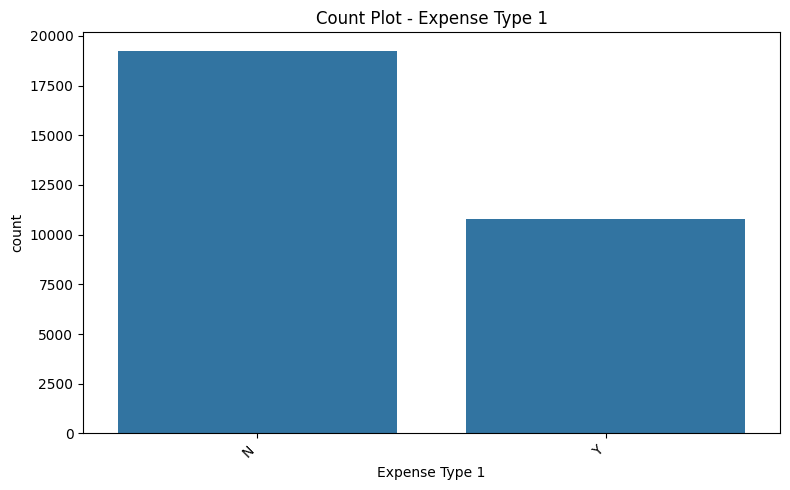

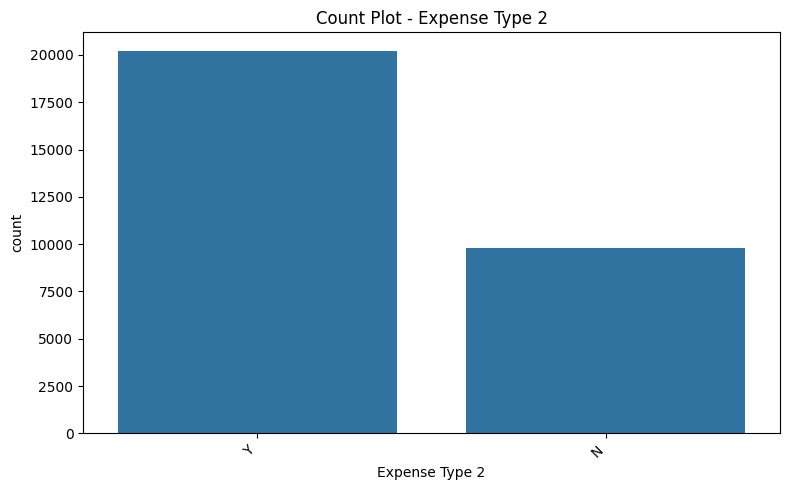

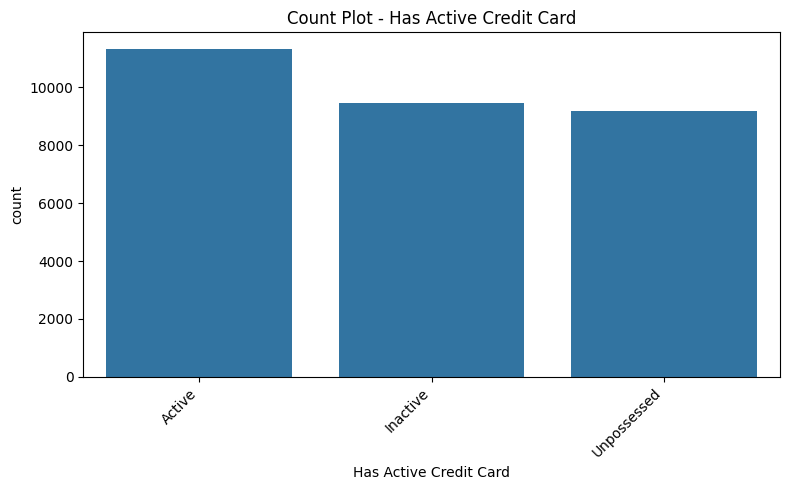

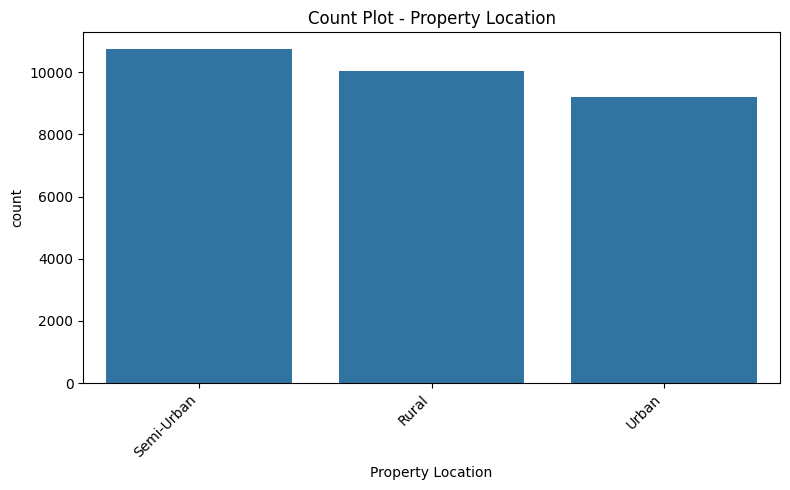

------------------------------------------------------------
CATEGORICAL ENCODING
Skipping Customer ID because it has too many categories.
Skipping Name because it has too many categories.
Gender: Binary encoding -> {'F': 0, 'M': 1}
Income Stability: Binary encoding -> {'Low': 0, 'High': 1}
Profession: One-hot encoded 
8 categories
Type of Employment: One-hot encoded 
18 categories
Location: One-hot encoded 
3 categories
Expense Type 1: Binary encoding -> {'N': 0, 'Y': 1}
Expense Type 2: Binary encoding -> {'N': 0, 'Y': 1}
Has Active Credit Card: One-hot encoded 
3 categories
Property Location: One-hot encoded 
3 categories
------------------------------------------------------------
FINAL DATASET
Final dimensions: (30000, 49)
Remaining columns:
['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)', 'Income Stability', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Proper

In [8]:
df = pd.read_csv("train.csv")
df = eda(df)

## 2. Train and Test split on dataset

In [9]:
from sklearn.model_selection import train_test_split
x = df.drop(columns= ["Loan Sanction Amount (USD)","Customer ID","Name"])
y = df["Loan Sanction Amount (USD)"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


## 3. Training Baseline Linear Regression, Ridge, Lasso and Elastic Net models

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
import time

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import  mean_squared_error
from sklearn.metrics import  r2_score

start_time = time.time()
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
training_time_lin = time.time() - start_time
y_pred_lin = linear_model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lin)

print("MAE of Baseline Linear Regression:", mae)
print("MSE of Baseline Linear Regression:", mse)
print("RMSE of Baseline Linear Regression:", rmse)
print("R2 Score of Baseline Linear Regression:", r2)
print("Training Time of Baseline Linear Regression::", training_time_lin, "seconds")

# 2. Ridge Regression
start_time = time.time()
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train, y_train)
training_time_rid = time.time() - start_time
y_pred_rid = ridge_model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred_rid)
mse = mean_squared_error(y_test, y_pred_rid)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rid)

print("MAE of Ridge Regression:", mae)
print("MSE of Ridge Regression:", mse)
print("RMSE of Ridge Regression:", rmse)
print("R2 Score of Ridge Regression:", r2)
print("Training Time of Ridge Regression:", training_time_rid, "seconds")

# 3. Lasso Regression
start_time = time.time()
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(x_train, y_train)
training_time_las = time.time() - start_time
y_pred_las = lasso_model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred_las)
mse = mean_squared_error(y_test, y_pred_las)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_las)

print("MAE of Lasso Regression:", mae)
print("MSE of Lasso Regression:", mse)
print("RMSE of Lasso Regression:", rmse)
print("R2 Score of Lasso Regression:", r2)
print("Training Time of Lasso Regression:", training_time_las, "seconds")

# 4. Elastic Net Regression
start_time = time.time()
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
elastic_model.fit(x_train, y_train)
training_time_elastic = time.time() - start_time
y_pred_elastic = elastic_model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred_elastic)
mse = mean_squared_error(y_test, y_pred_elastic)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_elastic)

print("MAE of Elastic Net Regression:", mae)
print("MSE of Elastic Net Regression:", mse)
print("RMSE of Elastic Net Regression:", rmse)
print("R2 Score of Elastic Net Regression:", r2)
print("Training Time of Elastic Net Regression:", training_time_elastic, "seconds")


MAE of Baseline Linear Regression: 0.5001726028595054
MSE of Baseline Linear Regression: 0.5075965096885172
RMSE of Baseline Linear Regression: 0.712458075740964
R2 Score of Baseline Linear Regression: 0.4904117674047649
Training Time of Baseline Linear Regression:: 0.07241344451904297 seconds
MAE of Ridge Regression: 0.5001690984409025
MSE of Ridge Regression: 0.5075927323362965
RMSE of Ridge Regression: 0.7124554248065604
R2 Score of Ridge Regression: 0.4904155595786772
Training Time of Ridge Regression: 0.016880273818969727 seconds
MAE of Lasso Regression: 0.5237930057246769
MSE of Lasso Regression: 0.5261085566275657
RMSE of Lasso Regression: 0.7253334106654441
R2 Score of Lasso Regression: 0.47182708232255544
Training Time of Lasso Regression: 0.07427740097045898 seconds
MAE of Elastic Net Regression: 0.5139698346248848
MSE of Elastic Net Regression: 0.5135460484196741
RMSE of Elastic Net Regression: 0.7166212726536061
R2 Score of Elastic Net Regression: 0.48443888368925714
Traini

## 4. Training Ridge, Lasso, Elastic Net models using GridsearchCV and RandomsearchCV  

In [11]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# Ridge using GridSearchCV
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}
start_time = time.time()
grid_ridge = GridSearchCV(Ridge(),ridge_params,cv=5,scoring="neg_mean_squared_error")
grid_ridge.fit(x_train, y_train)
training_time_grid_ridge = time.time() - start_time
y_pred_grid_ridge = grid_ridge.predict(x_test)
mae_grid_ridge = mean_absolute_error(y_test, y_pred_grid_ridge)
mse_grid_ridge = mean_squared_error(y_test, y_pred_grid_ridge)
rmse_grid_ridge = np.sqrt(mse_grid_ridge)
r2_grid_ridge = r2_score(y_test, y_pred_grid_ridge)

print("\nGRID SEARCH - RIDGE")
print("Best Parameters:", grid_ridge.best_params_)
print("MAE:", mae_grid_ridge)
print("MSE:", mse_grid_ridge)
print("RMSE:", rmse_grid_ridge)
print("R2 Score:", r2_grid_ridge)
print("Training Time:", training_time_grid_ridge, "seconds")


# Lasso using GridSearchCV

lasso_params = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
start_time = time.time()
grid_lasso = GridSearchCV(Lasso(max_iter=10000),lasso_params,cv=5,scoring="neg_mean_squared_error")
grid_lasso.fit(x_train, y_train)
training_time_grid_lasso = time.time() - start_time
y_pred_grid_lasso = grid_lasso.predict(x_test)
mae_grid_lasso = mean_absolute_error(y_test, y_pred_grid_lasso)
mse_grid_lasso = mean_squared_error(y_test, y_pred_grid_lasso)
rmse_grid_lasso = np.sqrt(mse_grid_lasso)
r2_grid_lasso = r2_score(y_test, y_pred_grid_lasso)

print("\nGRID SEARCH - LASSO")
print("Best Parameters:", grid_lasso.best_params_)
print("MAE:", mae_grid_lasso)
print("MSE:", mse_grid_lasso)
print("RMSE:", rmse_grid_lasso)
print("R2 Score:", r2_grid_lasso)
print("Training Time:", training_time_grid_lasso, "seconds")


# Elastic Net using GridSearchCV

elastic_params = {"alpha": [0.01, 0.1, 1, 10],"l1_ratio": [0.2, 0.5, 0.8]}
start_time = time.time()
grid_elastic = GridSearchCV(ElasticNet(max_iter=10000),elastic_params,cv=5,scoring="neg_mean_squared_error")
grid_elastic.fit(x_train, y_train)
training_time_grid_elastic = time.time() - start_time
y_pred_grid_elastic = grid_elastic.predict(x_test)
mae_grid_elastic = mean_absolute_error(y_test, y_pred_grid_elastic)
mse_grid_elastic = mean_squared_error(y_test, y_pred_grid_elastic)
rmse_grid_elastic = np.sqrt(mse_grid_elastic)
r2_grid_elastic = r2_score(y_test, y_pred_grid_elastic)

print("\nGRID SEARCH - ELASTIC NET")
print("Best Parameters:", grid_elastic.best_params_)
print("MAE:", mae_grid_elastic)
print("MSE:", mse_grid_elastic)
print("RMSE:", rmse_grid_elastic)
print("R2 Score:", r2_grid_elastic)
print("Training Time:", training_time_grid_elastic, "seconds")

# Ridge using RandomSearchCV

start_time = time.time()
random_ridge = RandomizedSearchCV(Ridge(),ridge_params,n_iter=5,cv=5,scoring="neg_mean_squared_error",random_state=42)
random_ridge.fit(x_train, y_train)
training_time_random_ridge = time.time() - start_time
y_pred_random_ridge = random_ridge.predict(x_test)
mae_random_ridge = mean_absolute_error(y_test,y_pred_random_ridge)
mse_random_ridge = mean_squared_error(y_test,y_pred_random_ridge)
rmse_random_ridge = np.sqrt(mse_random_ridge)
r2_random_ridge = r2_score(y_test,y_pred_random_ridge)

print("\nRANDOMIZED SEARCH - RIDGE")
print("Best Parameters:", random_ridge.best_params_)
print("MAE:", mae_random_ridge)
print("MSE:", mse_random_ridge)
print("RMSE:", rmse_random_ridge)
print("R2 Score:", r2_random_ridge)
print("Training Time:", training_time_random_ridge, "seconds")


# Lasso using Random Search CV

start_time = time.time()
random_lasso = RandomizedSearchCV(Lasso(max_iter=10000),lasso_params,n_iter=5,cv=5,scoring="neg_mean_squared_error",random_state=42)
random_lasso.fit(x_train, y_train)
training_time_random_lasso = time.time() - start_time
y_pred_random_lasso = random_lasso.predict(x_test)
mae_random_lasso = mean_absolute_error(y_test,y_pred_random_lasso)
mse_random_lasso = mean_squared_error(y_test,y_pred_random_lasso)
rmse_random_lasso = np.sqrt(mse_random_lasso)
r2_random_lasso = r2_score(y_test,y_pred_random_lasso)

print("\nRANDOMIZED SEARCH - LASSO")
print("Best Parameters:", random_lasso.best_params_)
print("MAE:", mae_random_lasso)
print("MSE:", mse_random_lasso)
print("RMSE:", rmse_random_lasso)
print("R2 Score:", r2_random_lasso)
print("Training Time:", training_time_random_lasso, "seconds")


# Elastic net using RandomSearchCV

start_time = time.time()
random_elastic = RandomizedSearchCV(ElasticNet(max_iter=10000),elastic_params,n_iter=12,cv=5,scoring="neg_mean_squared_error",random_state=42) 
random_elastic.fit(x_train, y_train)
training_time_random_elastic = time.time() - start_time
y_pred_random_elastic = random_elastic.predict(x_test)
mae_random_elastic = mean_absolute_error(y_test,y_pred_random_elastic)
mse_random_elastic = mean_squared_error(y_test,y_pred_random_elastic)
rmse_random_elastic = np.sqrt(mse_random_elastic)
r2_random_elastic = r2_score(y_test,y_pred_random_elastic)

print("\nRANDOMIZED SEARCH - ELASTIC NET")
print("Best Parameters:", random_elastic.best_params_)
print("MAE:", mae_random_elastic)
print("MSE:", mse_random_elastic)
print("RMSE:", rmse_random_elastic)
print("R2 Score:", r2_random_elastic)
print("Training Time:", training_time_random_elastic, "seconds")


GRID SEARCH - RIDGE
Best Parameters: {'alpha': 100}
MAE: 0.5002386081024391
MSE: 0.5071941964198596
RMSE: 0.7121756780597465
R2 Score: 0.490815659282687
Training Time: 0.5380463600158691 seconds

GRID SEARCH - LASSO
Best Parameters: {'alpha': 0.001}
MAE: 0.49994815527002806
MSE: 0.5072653902810248
RMSE: 0.7122256596620378
R2 Score: 0.4907441860688444
Training Time: 4.881348371505737 seconds

GRID SEARCH - ELASTIC NET
Best Parameters: {'alpha': 0.01, 'l1_ratio': 0.2}
MAE: 0.5009895153763609
MSE: 0.5066325629259856
RMSE: 0.7117812605892245
R2 Score: 0.49137949653146007
Training Time: 5.851212978363037 seconds

RANDOMIZED SEARCH - RIDGE
Best Parameters: {'alpha': 100}
MAE: 0.5002386081024391
MSE: 0.5071941964198596
RMSE: 0.7121756780597465
R2 Score: 0.490815659282687
Training Time: 0.5129718780517578 seconds

RANDOMIZED SEARCH - LASSO
Best Parameters: {'alpha': 0.001}
MAE: 0.49994815527002806
MSE: 0.5072653902810248
RMSE: 0.7122256596620378
R2 Score: 0.4907441860688444
Training Time: 4.9

## 5. Visualizations

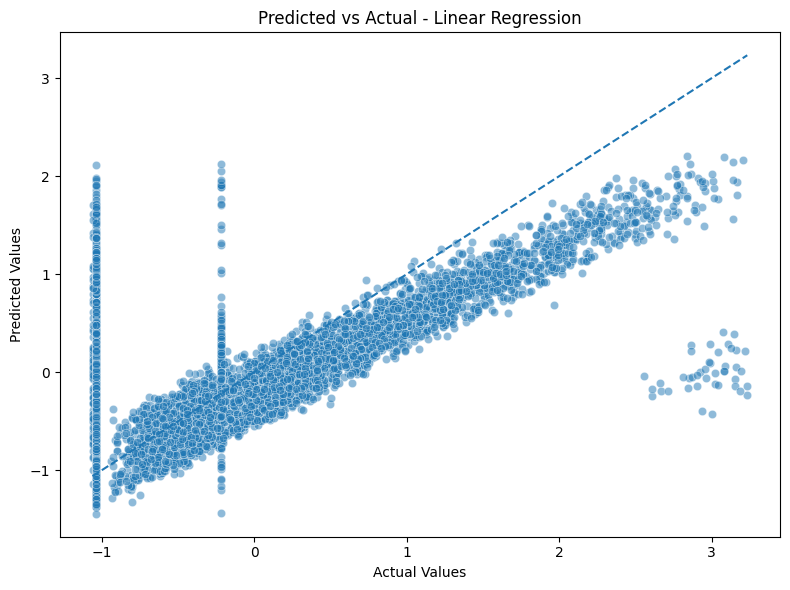

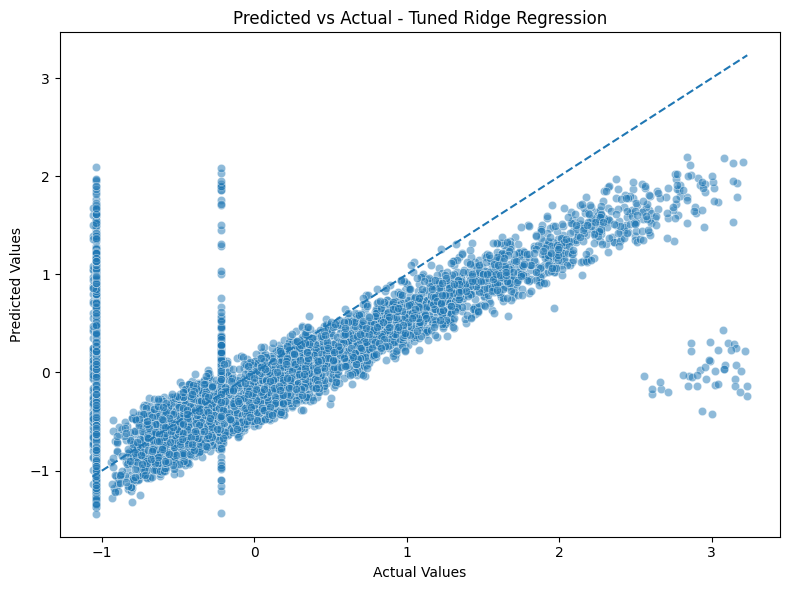

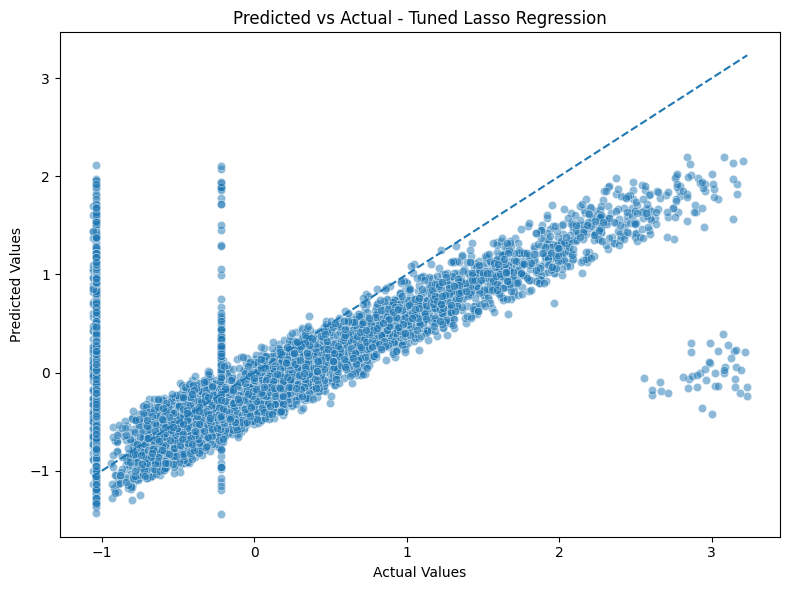

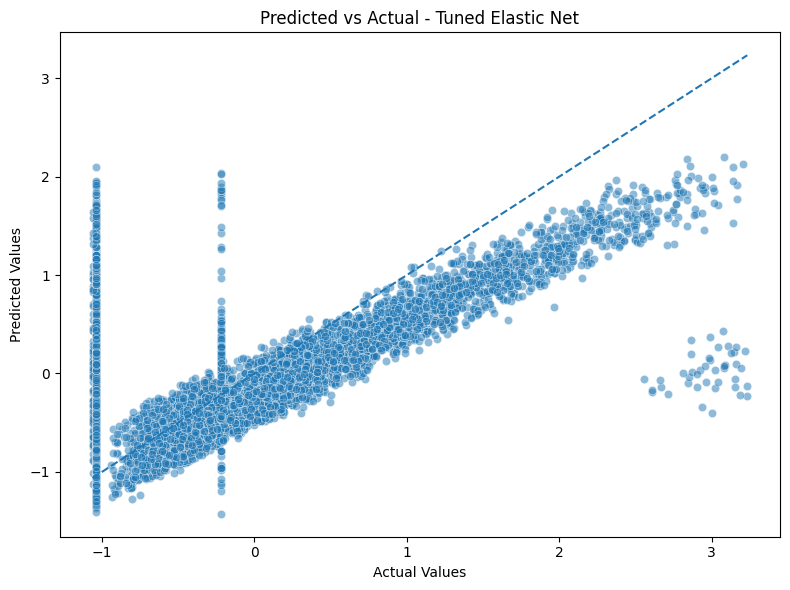

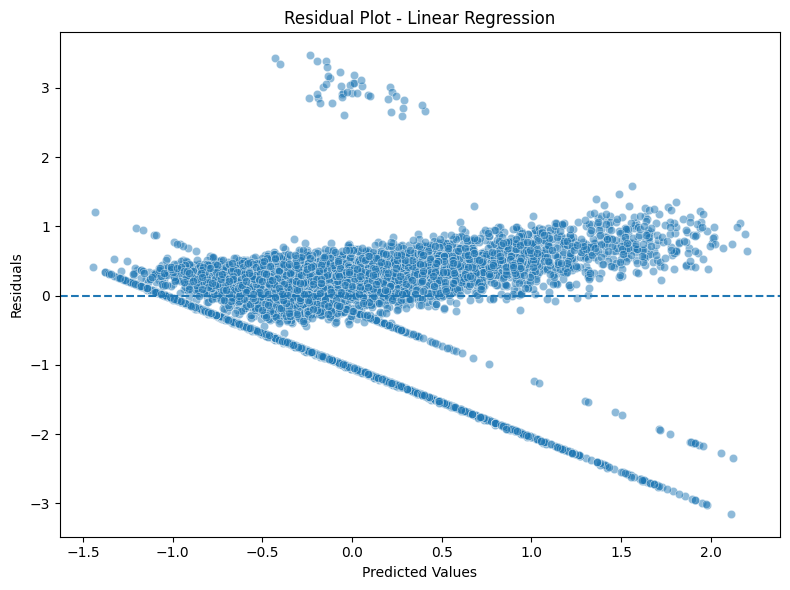

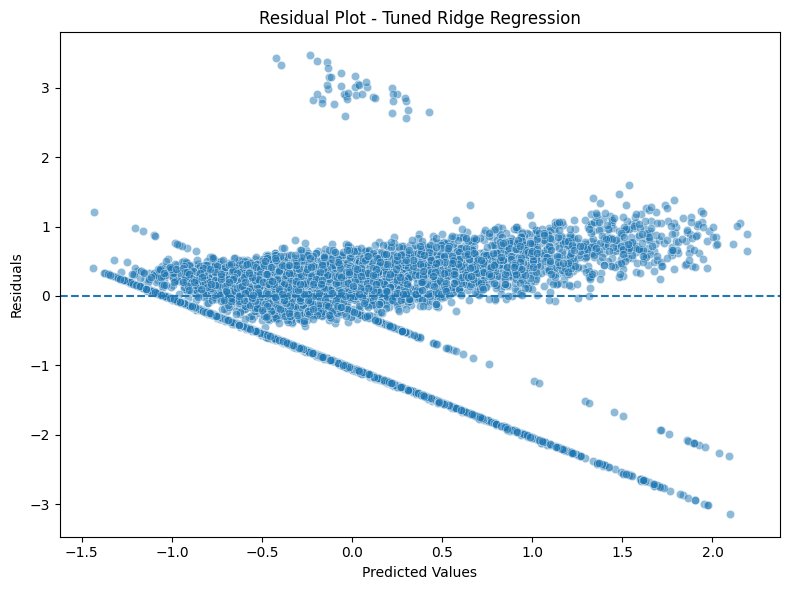

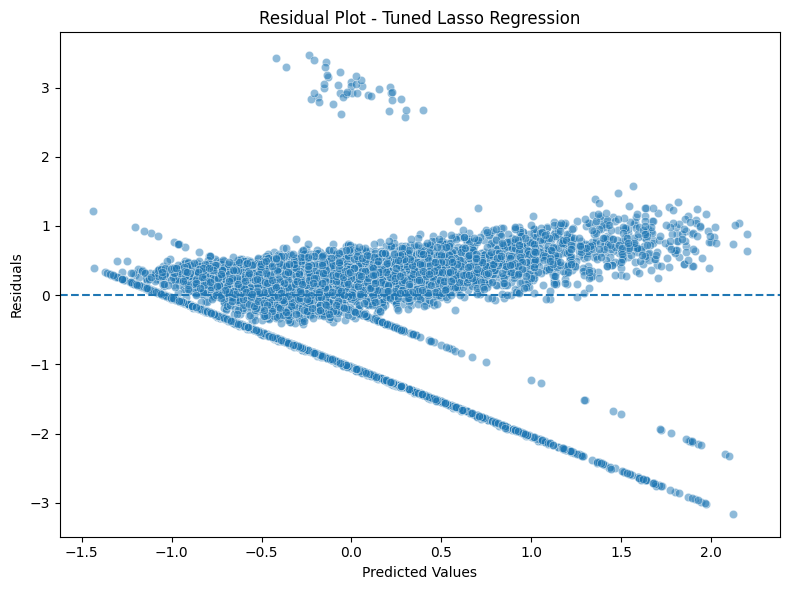

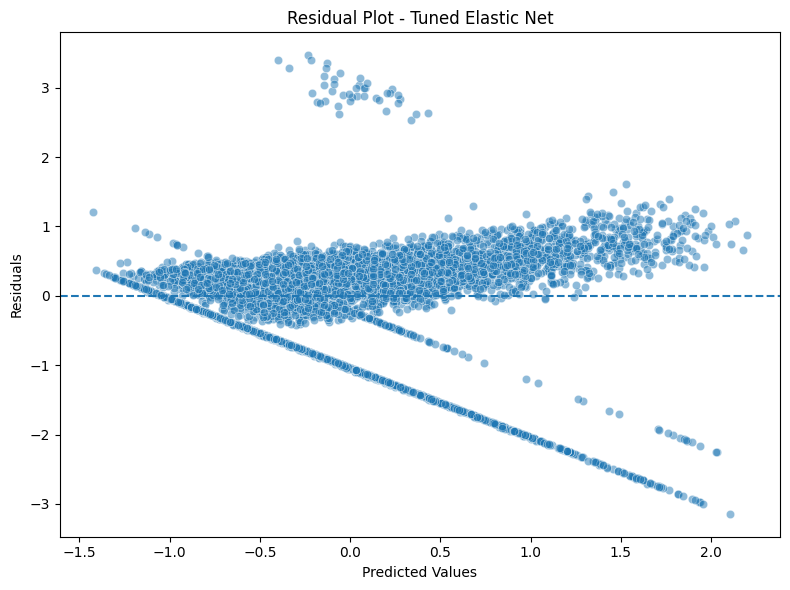

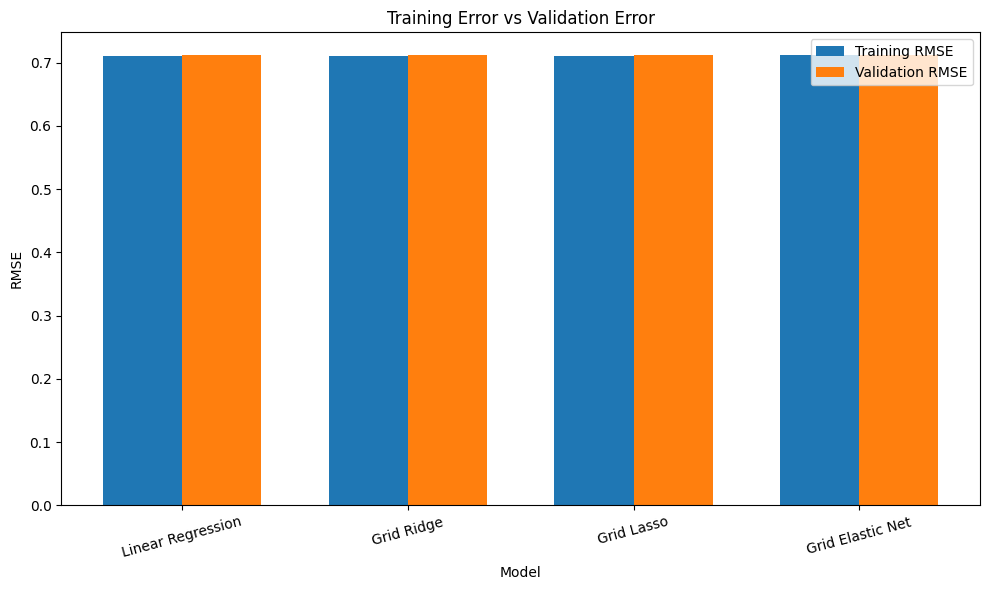

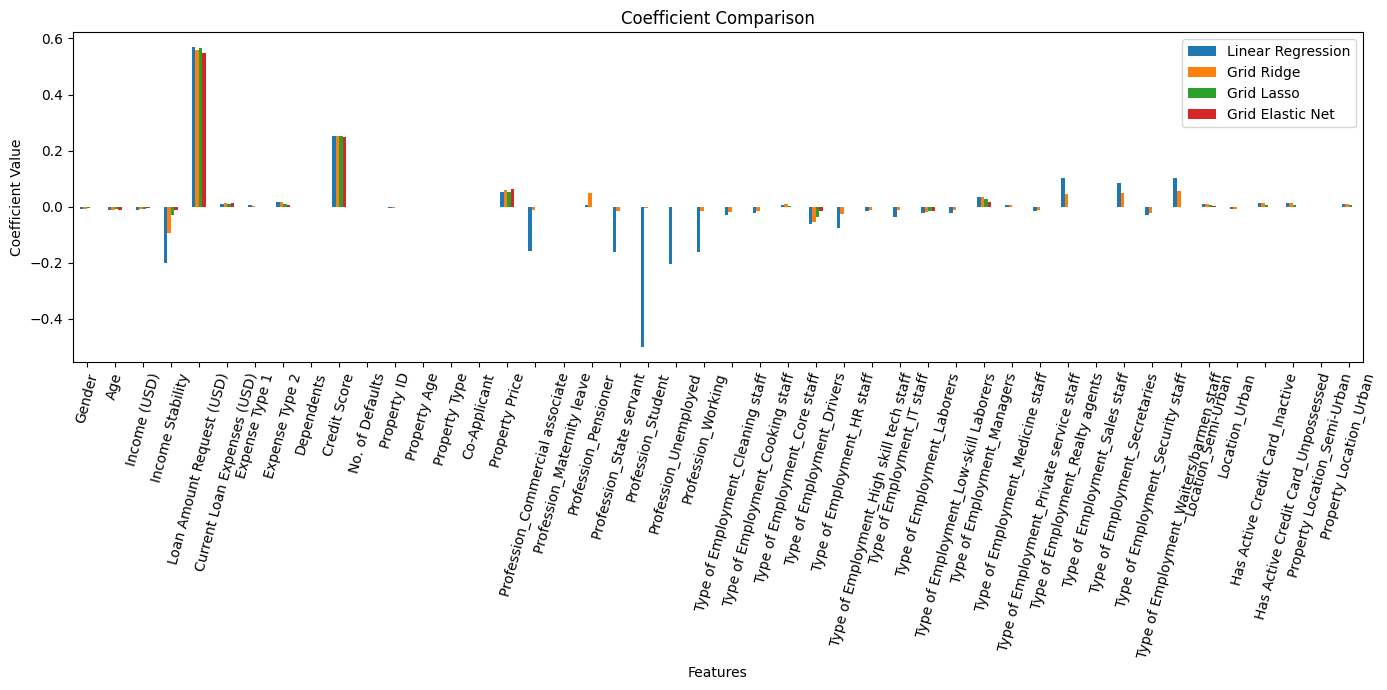

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted vs actual values

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred_lin,alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linestyle="--")
plt.title("Predicted vs Actual - Linear Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred_grid_ridge,alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linestyle="--")
plt.title("Predicted vs Actual - Tuned Ridge Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred_grid_lasso,alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linestyle="--")
plt.title("Predicted vs Actual - Tuned Lasso Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=y_pred_grid_elastic,alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linestyle="--")
plt.title("Predicted vs Actual - Tuned Elastic Net")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

# Residual Plots

residual_lin = y_test - y_pred_lin
residual_grid_ridge = y_test - y_pred_grid_ridge
residual_grid_lasso = y_test - y_pred_grid_lasso
residual_grid_elastic = y_test - y_pred_grid_elastic


plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_lin,y=residual_lin,alpha=0.5)
plt.axhline(0,linestyle="--")
plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_grid_ridge,y=residual_grid_ridge,alpha=0.5)
plt.axhline(0,linestyle="--")
plt.title("Residual Plot - Tuned Ridge Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_grid_lasso,y=residual_grid_lasso,alpha=0.5)
plt.axhline(0,linestyle="--")
plt.title("Residual Plot - Tuned Lasso Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_grid_elastic,y=residual_grid_elastic,alpha=0.5)
plt.axhline(0,linestyle="--")
plt.title("Residual Plot - Tuned Elastic Net")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

# Training error vs Validation error

train_pred_lin = linear_model.predict(x_train)
train_pred_grid_ridge = grid_ridge.predict(x_train)
train_pred_grid_lasso = grid_lasso.predict(x_train)
train_pred_grid_elastic = grid_elastic.predict(x_train)


train_rmse_lin = np.sqrt(mean_squared_error(y_train, train_pred_lin))
train_rmse_grid_ridge = np.sqrt(mean_squared_error(y_train, train_pred_grid_ridge))
train_rmse_grid_lasso = np.sqrt(mean_squared_error(y_train, train_pred_grid_lasso))
train_rmse_grid_elastic = np.sqrt(mean_squared_error(y_train, train_pred_grid_elastic))
validation_rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
validation_rmse_grid_ridge = np.sqrt(mean_squared_error(y_test, y_pred_grid_ridge))
validation_rmse_grid_lasso = np.sqrt(mean_squared_error(y_test, y_pred_grid_lasso))
validation_rmse_grid_elastic = np.sqrt(mean_squared_error(y_test, y_pred_grid_elastic))
models = ["Linear Regression","Grid Ridge","Grid Lasso","Grid Elastic Net"]
training_errors = [train_rmse_lin,train_rmse_grid_ridge,train_rmse_grid_lasso,train_rmse_grid_elastic]
validation_errors = [validation_rmse_lin,validation_rmse_grid_ridge,validation_rmse_grid_lasso,validation_rmse_grid_elastic]
x = np.arange(len(models))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width / 2,training_errors,width,label="Training RMSE")
plt.bar(x + width / 2,validation_errors,width,label="Validation RMSE")
plt.xticks(x,models,rotation=15)
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Training Error vs Validation Error")
plt.legend()
plt.tight_layout()
plt.show()

# Coefficient Comparison

coefficient_df = pd.DataFrame({
    "Linear Regression": linear_model.coef_,
    "Grid Ridge": grid_ridge.best_estimator_.coef_,
    "Grid Lasso": grid_lasso.best_estimator_.coef_,
    "Grid Elastic Net": grid_elastic.best_estimator_.coef_
})
coefficient_df.index = x_train.columns
coefficient_df.plot(kind="bar",figsize=(14, 7))
plt.title("Coefficient Comparison")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=75)
plt.legend()
plt.tight_layout()
plt.show()
